**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [2]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path(
    r"F:\桌面\AI_Robot_Learning\AI\CS231n\assignment\assignment1"
)

assert PROJECT_ROOT.exists(), f"项目路径不存在：{PROJECT_ROOT}"
assert (PROJECT_ROOT / "cs231n").exists(), "没有找到 cs231n 文件夹"

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Python解释器：", sys.executable)
print("当前工作目录：", Path.cwd())

Python解释器： F:\conda_envs\cs231n-a1\python.exe
当前工作目录： F:\桌面\AI_Robot_Learning\AI\CS231n\assignment\assignment1


# Image features exercise
*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

We have seen that we can achieve reasonable performance on an image classification task by training a linear classifier on the pixels of the input image. In this exercise we will show that we can improve our classification performance by training linear classifiers not on raw pixels but on features that are computed from the raw pixels.

All of your work for this exercise will be done in this notebook.

In [3]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## Load data
Similar to previous exercises, we will load CIFAR-10 data from disk.

In [4]:
from cs231n.features import color_histogram_hsv, hog_feature

def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

    # Subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    return X_train, y_train, X_val, y_val, X_test, y_test

X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()

#增加形状检查
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (49000, 32, 32, 3)
y_train: (49000,)
X_val  : (1000, 32, 32, 3)
y_val  : (1000,)
X_test : (1000, 32, 32, 3)
y_test : (1000,)


## Extract Features
For each image we will compute a Histogram of Oriented
Gradients (HOG) as well as a color histogram using the hue channel in HSV
color space. We form our final feature vector for each image by concatenating
the HOG and color histogram feature vectors.

Roughly speaking, HOG should capture the texture of the image while ignoring
color information, and the color histogram represents the color of the input
image while ignoring texture. As a result, we expect that using both together
ought to work better than using either alone. Verifying this assumption would
be a good thing to try for your own interest.

The `hog_feature` and `color_histogram_hsv` functions both operate on a single
image and return a feature vector for that image. The extract_features
function takes a set of images and a list of feature functions and evaluates
each feature function on each image, storing the results in a matrix where
each column is the concatenation of all feature vectors for a single image.

In [5]:
from cs231n.features import *

# num_color_bins = 10 # Number of bins in the color histogram
num_color_bins = 25 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_val_feats = extract_features(X_val, feature_fns)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_val_feats = np.hstack([X_val_feats, np.ones((X_val_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

Done extracting features for 1000 / 49000 images
Done extracting features for 2000 / 49000 images
Done extracting features for 3000 / 49000 images
Done extracting features for 4000 / 49000 images
Done extracting features for 5000 / 49000 images
Done extracting features for 6000 / 49000 images
Done extracting features for 7000 / 49000 images
Done extracting features for 8000 / 49000 images
Done extracting features for 9000 / 49000 images
Done extracting features for 10000 / 49000 images
Done extracting features for 11000 / 49000 images
Done extracting features for 12000 / 49000 images
Done extracting features for 13000 / 49000 images
Done extracting features for 14000 / 49000 images
Done extracting features for 15000 / 49000 images
Done extracting features for 16000 / 49000 images
Done extracting features for 17000 / 49000 images
Done extracting features for 18000 / 49000 images
Done extracting features for 19000 / 49000 images
Done extracting features for 20000 / 49000 images
Done extr

In [6]:
# 检查一下
print("训练特征：", X_train_feats.shape)
print("验证特征：", X_val_feats.shape)
print("测试特征：", X_test_feats.shape)

print("是否存在 NaN：", np.isnan(X_train_feats).any())
print("是否存在 Inf：", np.isinf(X_train_feats).any())

训练特征： (49000, 170)
验证特征： (1000, 170)
测试特征： (1000, 170)
是否存在 NaN： False
是否存在 Inf： False


In [8]:
# 特征标准化
mean_feat = np.mean(
    X_train_feats,
    axis=0,
    keepdims=True
)

X_train_feats -= mean_feat
X_val_feats -= mean_feat
X_test_feats -= mean_feat

# 除以标准差
std_feat = np.std(
    X_train_feats,
    axis=0,
    keepdims=True
)

std_feat[std_feat < 1e-12] = 1.0

X_train_feats /= std_feat
X_val_feats /= std_feat
X_test_feats /= std_feat

In [9]:
# 为sfotmax增加偏置维度
X_train_feats = np.hstack([
    X_train_feats,
    np.ones((X_train_feats.shape[0], 1))
])

X_val_feats = np.hstack([
    X_val_feats,
    np.ones((X_val_feats.shape[0], 1))
])

X_test_feats = np.hstack([
    X_test_feats,
    np.ones((X_test_feats.shape[0], 1))
])

# 检查结果应为1
print("训练特征：", X_train_feats.shape)
print("验证特征：", X_val_feats.shape)
print("测试特征：", X_test_feats.shape)

print(
    "最后一列是否全为1：",
    np.allclose(X_train_feats[:, -1], 1)
)

训练特征： (49000, 171)
验证特征： (1000, 171)
测试特征： (1000, 171)
最后一列是否全为1： True


## Train Softmax classifier on features
Using the Softmax code developed earlier in the assignment, train Softmax classifiers on top of the features extracted above; this should achieve better results than training them directly on top of raw pixels.

In [10]:
# Use the validation set to tune the learning rate and regularization strength

from cs231n.classifiers.linear_classifier import Softmax

learning_rates = [1e-7, 5e-7, 1e-6] #扩展候选范围
regularization_strengths = [5e4, 5e5, 5e6]

results = {}
best_val = -1
best_softmax = None

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the Softmax; save#
# the best trained classifer in best_softmax. If you carefully tune the model, #
# you should be able to get accuracy of above 0.42 on the validation set.      #
################################################################################
for learning_rate in learning_rates:
    for regularization_strength in regularization_strengths:
        np.random.seed(0)

        model = Softmax()

        model.train(
            X_train_feats,
            y_train,
            learning_rate=learning_rate,
            reg=regularization_strength,
            num_iters=1500,
            batch_size=200,
            verbose=False
        )

        y_train_pred = model.predict(X_train_feats)
        train_accuracy = np.mean(
            y_train_pred == y_train
        )

        y_val_pred = model.predict(X_val_feats)
        val_accuracy = np.mean(
            y_val_pred == y_val
        )

        results[
            (
                learning_rate,
                regularization_strength
            )
        ] = (
            train_accuracy,
            val_accuracy
        )

        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = model



# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved: %f' % best_val)

F:\桌面\AI_Robot_Learning\AI\CS231n\assignment\assignment1\cs231n\classifiers\softmax.py:120: RuntimeWarning: overflow encountered in scalar multiply
  loss += reg * np.sum(W * W)
F:\conda_envs\cs231n-a1\Lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
F:\桌面\AI_Robot_Learning\AI\CS231n\assignment\assignment1\cs231n\classifiers\softmax.py:120: RuntimeWarning: overflow encountered in multiply
  loss += reg * np.sum(W * W)
F:\桌面\AI_Robot_Learning\AI\CS231n\assignment\assignment1\cs231n\classifiers\softmax.py:138: RuntimeWarning: overflow encountered in multiply
  dW += 2 * reg * W


lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.423143 val accuracy: 0.425000
lr 1.000000e-07 reg 5.000000e+05 train accuracy: 0.416122 val accuracy: 0.423000
lr 1.000000e-07 reg 5.000000e+06 train accuracy: 0.328633 val accuracy: 0.309000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.420551 val accuracy: 0.421000
lr 5.000000e-07 reg 5.000000e+05 train accuracy: 0.371122 val accuracy: 0.358000
lr 5.000000e-07 reg 5.000000e+06 train accuracy: 0.100265 val accuracy: 0.087000
lr 1.000000e-06 reg 5.000000e+04 train accuracy: 0.416122 val accuracy: 0.423000
lr 1.000000e-06 reg 5.000000e+05 train accuracy: 0.328633 val accuracy: 0.309000
lr 1.000000e-06 reg 5.000000e+06 train accuracy: 0.100265 val accuracy: 0.087000
best validation accuracy achieved: 0.425000


In [11]:
# Evaluate your trained Softmax on the test set: you should be able to get at least 0.42
y_test_pred = best_softmax.predict(X_test_feats)
test_accuracy = np.mean(y_test == y_test_pred)
print(test_accuracy)

0.423


In [12]:
# Save best softmax model
best_softmax.save("best_softmax_features.npy")

best_softmax_features.npy saved.


In [ ]:
# An important way to gain intuition about how an algorithm works is to
# visualize the mistakes that it makes. In this visualization, we show examples
# of images that are misclassified by our current system. The first column
# shows images that our system labeled as "plane" but whose true label is
# something other than "plane".

examples_per_class = 8
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for cls, cls_name in enumerate(classes):
    idxs = np.where((y_test != cls) & (y_test_pred == cls))[0]
    idxs = np.random.choice(idxs, examples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt.subplot(examples_per_class, len(classes), i * len(classes) + cls + 1)
        plt.imshow(X_test[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls_name)
plt.show()

### Inline question 1:
Describe the misclassification results that you see. Do they make sense?


$\color{blue}{\textit Your Answer:}$这些分类错误的结果总体上是合理的。许多被错误分类的图像在颜色、纹理或大致形状上与预测类别存在相似之处。例如，汽车和卡车可能会被混淆，因为两者都包含相似的水平边缘和车辆特有的结构；猫、狗、鹿和马也可能因具有相似的动物纹理和身体轮廓而被混淆；当飞机和船只都出现在大面积蓝色背景中时，有时也容易被混淆。

这些错误反映了图像特征本身的局限性。HOG（方向梯度直方图）描述符虽然能捕捉局部边缘方向和大致形状，却无法充分表征物体的细节部位或其精确的空间布局。HSV颜色直方图虽然能捕捉整体颜色分布，却忽略了各种颜色在图像中的具体位置。因此，即使两幅图像包含不同的物体，只要它们的颜色和边缘模式相似，就可能产生相似的特征向量。

此外，Softmax分类器属于线性分类器，无法对提取出的特征之间高度复杂的关系进行建模。总而言之，这些错误在情理之中，因为该分类器主要依赖于大致形状、纹理和颜色信息，而非对物体进行深入的语义理解。





## Neural Network on image features
Earlier in this assigment we saw that training a two-layer neural network on raw pixels achieved better classification performance than linear classifiers on raw pixels. In this notebook we have seen that linear classifiers on image features outperform linear classifiers on raw pixels.

For completeness, we should also try training a neural network on image features. This approach should outperform all previous approaches: you should easily be able to achieve over 55% classification accuracy on the test set; our best model achieves about 60% classification accuracy.

In [13]:
# Preprocessing: Remove the bias dimension
# Make sure to run this cell only ONCE
print(X_train_feats.shape)
X_train_feats = X_train_feats[:, :-1]
X_val_feats = X_val_feats[:, :-1]
X_test_feats = X_test_feats[:, :-1]

print(X_train_feats.shape)

(49000, 171)
(49000, 170)


In [22]:
print("X_train_feats:", X_train_feats.shape)
print("X_val_feats:", X_val_feats.shape)

print("NaN:", np.isnan(X_train_feats).any())
print("Inf:", np.isinf(X_train_feats).any())

print("Mean:", np.mean(X_train_feats))
print("Std:", np.std(X_train_feats))

print(
    "最后一列是否仍是全1偏置列：",
    np.allclose(X_train_feats[:, -1], 1.0)
)

X_train_feats: (49000, 170)
X_val_feats: (1000, 170)
NaN: False
Inf: False
Mean: -1.5546640938731796e-17
Std: 0.9970544855015818
最后一列是否仍是全1偏置列： False


In [23]:
print("Best validation accuracy:", best_solver.best_val_acc)
print("Highest training accuracy:", max(best_solver.train_acc_history))
print("Final training accuracy:", best_solver.train_acc_history[-1])
print("Final validation accuracy:", best_solver.val_acc_history[-1])

Best validation accuracy: 0.462
Highest training accuracy: 0.488
Final training accuracy: 0.488
Final validation accuracy: 0.462


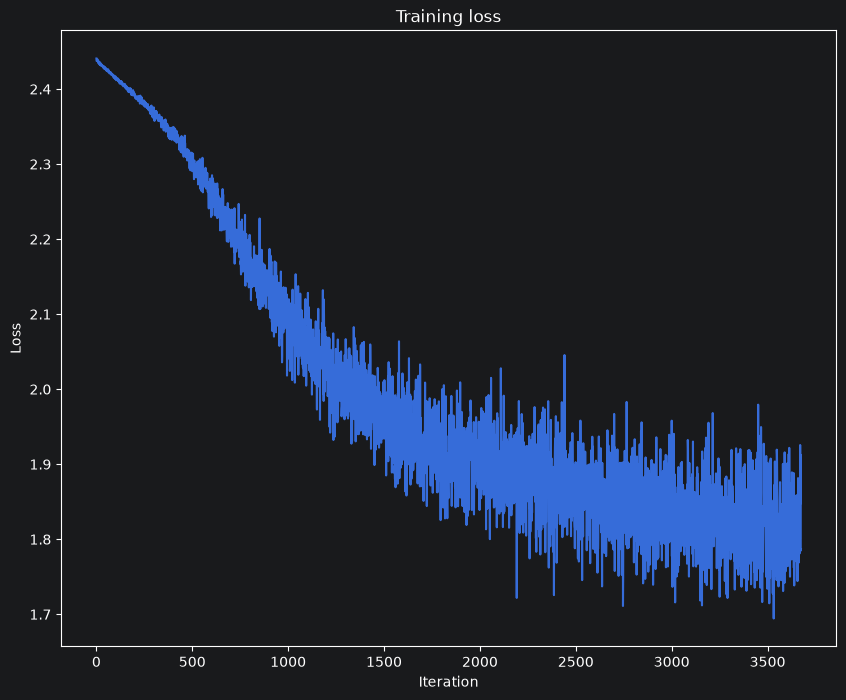

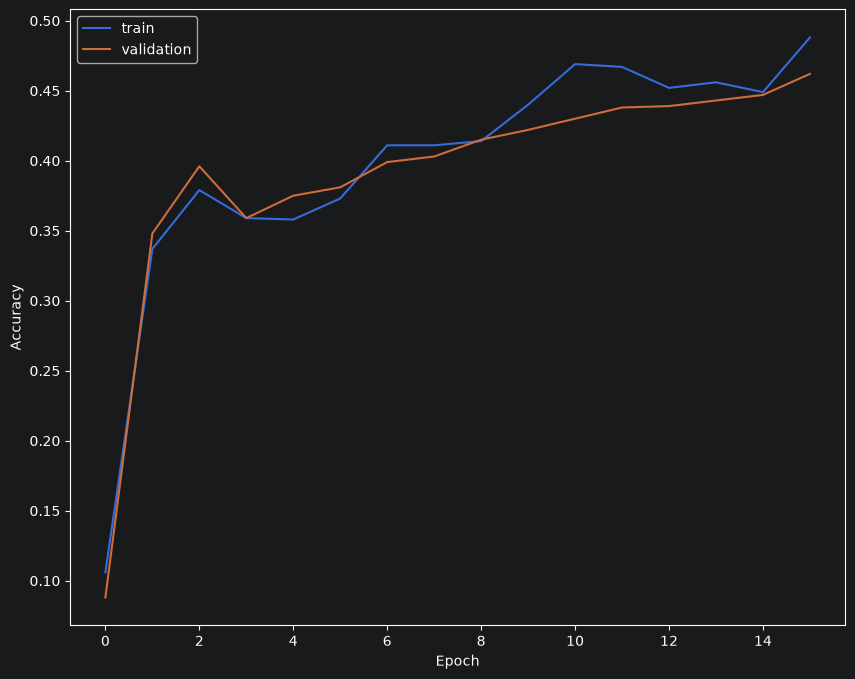

In [24]:
plt.plot(best_solver.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

plt.plot(best_solver.train_acc_history, label="train")
plt.plot(best_solver.val_acc_history, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [27]:
from cs231n.classifiers.fc_net import TwoLayerNet
from cs231n.solver import Solver

np.random.seed(231)

strong_model = TwoLayerNet(
    input_dim=X_train_feats.shape[1],
    hidden_dim=500,
    num_classes=10,
    weight_scale=5e-2,
    reg=1e-3
)

strong_solver = Solver(
    strong_model,
    data,
    update_rule="sgd",
    optim_config={
        "learning_rate": 1e-1
    },
    lr_decay=0.95,
    num_epochs=25,
    batch_size=200,
    print_every=100,
    verbose=True
)

strong_solver.train()

print(
    "Best validation accuracy:",
    strong_solver.best_val_acc
)

print(
    "Highest training accuracy:",
    max(strong_solver.train_acc_history)
)

#原有代码别动
net = TwoLayerNet(input_dim, hidden_dim, num_classes)
best_net = None

candidate_configs = [
    # hidden, learning_rate, reg, weight_scale
    (300, 5e-2, 1e-4, 2e-2),
    (300, 1e-1, 1e-4, 5e-2),
    (300, 5e-2, 1e-3, 5e-2),

    (500, 3e-2, 1e-4, 5e-2),
    (500, 5e-2, 1e-4, 5e-2),
    (500, 1e-1, 1e-4, 5e-2),
    (500, 5e-2, 1e-3, 5e-2),
    (500, 1e-1, 1e-3, 5e-2),

    (800, 3e-2, 1e-4, 2e-2),
    (800, 5e-2, 1e-4, 5e-2),
    (800, 5e-2, 1e-3, 5e-2),
    (800, 1e-1, 1e-3, 5e-2),
]

################################################################################
# TODO: Train a two-layer neural network on image features. You may want to    #
# cross-validate various parameters as in previous sections. Store your best   #
# model in the best_net variable.                                              #
################################################################################
net = TwoLayerNet(
    input_dim=input_dim,
    hidden_dim=500,
    num_classes=num_classes,
    weight_scale=1e-2,
    reg=0.1
)

solver = Solver(
    net,
    data,
    update_rule="sgd",
    optim_config={
        "learning_rate": 1e-2
    },
    lr_decay=0.95,
    num_epochs=15,
    batch_size=200,
    print_every=100,
    verbose=True
)

solver.train()

hidden_dims = [
    300,
    500
]

learning_rates = [
    5e-3,
    1e-2
]

regularization_strengths = [
    0.05,
    0.1
]

weight_scales = [
    5e-3,
    1e-2
]

best_net = None
best_solver = None
best_val_accuracy = -1.0
results = {}
nn_results = {}

input_dim = X_train_feats.shape[1]
num_classes = 10

for hidden_dim, learning_rate, reg, weight_scale in candidate_configs:
    np.random.seed(231)

    model = TwoLayerNet(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_classes=num_classes,
        weight_scale=weight_scale,
        reg=reg
    )

    solver = Solver(
        model,
        data,
        update_rule="sgd",
        optim_config={
            "learning_rate": learning_rate
        },
        lr_decay=0.95,
        num_epochs=25,
        batch_size=200,
        print_every=200,
        verbose=False
    )

    solver.train()

    train_acc = max(solver.train_acc_history)
    val_acc = solver.best_val_acc

    key = (
        hidden_dim,
        learning_rate,
        reg,
        weight_scale
    )

    results[key] = (train_acc, val_acc)

    print(
        "hidden=%d lr=%e reg=%e scale=%e "
        "train=%.4f val=%.4f"
        % (
            hidden_dim,
            learning_rate,
            reg,
            weight_scale,
            train_acc,
            val_acc
        )
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_net = model
        best_solver = solver

print("\nBest validation accuracy:", best_val_accuracy)

(Iteration 1 / 6125) loss: 2.517527
(Epoch 0 / 25) train acc: 0.129000; val_acc: 0.138000
(Iteration 101 / 6125) loss: 1.442134
(Iteration 201 / 6125) loss: 1.487223
(Epoch 1 / 25) train acc: 0.517000; val_acc: 0.518000
(Iteration 301 / 6125) loss: 1.533344
(Iteration 401 / 6125) loss: 1.455522
(Epoch 2 / 25) train acc: 0.546000; val_acc: 0.544000
(Iteration 501 / 6125) loss: 1.347403
(Iteration 601 / 6125) loss: 1.468686
(Iteration 701 / 6125) loss: 1.265133
(Epoch 3 / 25) train acc: 0.563000; val_acc: 0.551000
(Iteration 801 / 6125) loss: 1.256291
(Iteration 901 / 6125) loss: 1.171738
(Epoch 4 / 25) train acc: 0.598000; val_acc: 0.566000
(Iteration 1001 / 6125) loss: 1.304314
(Iteration 1101 / 6125) loss: 1.207218
(Iteration 1201 / 6125) loss: 1.310264
(Epoch 5 / 25) train acc: 0.620000; val_acc: 0.560000
(Iteration 1301 / 6125) loss: 1.149740
(Iteration 1401 / 6125) loss: 1.237194
(Epoch 6 / 25) train acc: 0.641000; val_acc: 0.581000
(Iteration 1501 / 6125) loss: 1.128644
(Iteration

In [28]:
# Run your best neural net classifier on the test set. You should be able
# to get more than 58% accuracy. It is also possible to get >60% accuracy
# with careful tuning.

y_test_pred = np.argmax(best_net.loss(data['X_test']), axis=1)
test_acc = (y_test_pred == data['y_test']).mean()
print(test_acc)

0.592


In [29]:
# Save best model
best_net.save("best_two_layer_net_features.npy")

best_two_layer_net_features.npy saved.
